In [1]:
import tensorflow as tf
from tensorflow import keras
import dataset_utils
import training_utils
import os
import classifier_model
import segmentation_model
BATCH_SIZE = 32


Num GPUs Available:  0
Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
False


In [10]:
import importlib
importlib.reload(segmentation_model)
importlib.reload(dataset_utils)

<module 'dataset_utils' from 'c:\\Users\\yravan\\Documents\\wildfire_detection\\organized_code\\dataset_utils.py'>

In [4]:
classification_model_all_bands = classifier_model.build_model(12, 'simple', None)
classification_model_all_bands.load_weights('./data/model_weights/enc_16_classification_bands_all_trial1.keras')
classification_model_all_bands.compile(
    loss=keras.losses.BinaryCrossentropy(from_logits=True),
    optimizer=keras.optimizers.Adam(learning_rate=0.0005,beta_1=0.9,beta_2=0.999,epsilon=1e-07,),
    metrics=[
      keras.metrics.BinaryAccuracy(name='accuracy'),
      keras.metrics.Precision(name='precision'),
      keras.metrics.Recall(name='recall'),
    ],
)
classification_model_all_bands.summary()

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 256, 256, 12)]    0         
                                                                 
 conv1 (Conv2D)              (None, 128, 128, 1)       589       
                                                                 
 batch_normalization_6 (Batc  (None, 128, 128, 1)      4         
 hNormalization)                                                 
                                                                 
 maxpool1 (MaxPooling2D)     (None, 64, 64, 1)         0         
                                                                 
 conv3 (Conv2D)              (None, 32, 32, 2)         100       
                                                                 
 batch_normalization_7 (Batc  (None, 32, 32, 2)        8         
 hNormalization)                                           

In [6]:
segmentation_model_all_bands = segmentation_model.get_trimmed_unet_model(input_channel_count=12, output_channels=1)
segmentation_model_all_bands.load_weights('./data/model_weights/enc_16_segmentation_bands_all_trial1.keras')
segmentation_model_all_bands.compile(
                optimizer= tf.keras.optimizers.Adam(learning_rate=3e-04), # tf.keras.optimizers.SGD(learning_rate=0.01), 
                loss= tf.keras.losses.BinaryCrossentropy(), # tf.keras.losses.BinaryCrossentropy(),
                metrics=[segmentation_model.IOU(num_classes=2),
      keras.metrics.BinaryAccuracy(name='accuracy'),
      keras.metrics.Precision(name='precision'),
      keras.metrics.Recall(name='recall')],
                weighted_metrics=[]
            )
segmentation_model_all_bands.summary()

Model: "U-Net"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_5 (InputLayer)           [(None, 256, 256, 1  0           []                               
                                2)]                                                               
                                                                                                  
 conv2d_11 (Conv2D)             (None, 256, 256, 32  3488        ['input_5[0][0]']                
                                )                                                                 
                                                                                                  
 conv2d_12 (Conv2D)             (None, 256, 256, 32  9248        ['conv2d_11[0][0]']              
                                )                                                             

In [16]:
num_images_test , new_test_dataset = dataset_utils.get_dataset(list(range(1,13)), './ata/ams_data/processed_images/patches/train/images', './data/ams_data/processed_images/patches/train/labels', dataset_name=None, dataset_source='AMS', dataset_type='classification', test=False)
new_test_dataset = new_test_dataset.shuffle(1024).batch(BATCH_SIZE)

balanced_test_dataset = dataset_utils.balance_dataset(new_test_dataset, num_images=num_images_test)
balanced_test_dataset = balanced_test_dataset.shuffle(1024).batch(BATCH_SIZE)
# balanced_test_dataset = balanced_test_dataset.cache().apply(tf.data.experimental.prefetch_to_device("/gpu:0"))
print(num_images_test)


0


2024-01-25 14:44:32.085257: W tensorflow/core/data/root_dataset.cc:266] Optimization loop failed: CANCELLED: Operation was cancelled


In [17]:
num_images_test , segmentation_test_dataset = dataset_utils.get_dataset(list(range(1,13)), './data/ams_data/processed_images/patches/train/images', './data/ams_data/processed_images/patches/train/labels', dataset_name=None, dataset_source='AMS', dataset_type='segmentation', test=False)
balanced_segmentation_test_dataset = segmentation_test_dataset.shuffle(1024).batch(BATCH_SIZE)

# balanced_segmentation_test_dataset = balanced_segmentation_test_dataset.cache().apply(tf.data.experimental.prefetch_to_device("/gpu:0"))
print(num_images_test)



0


In [18]:
classification_model_all_bands.evaluate(balanced_test_dataset, verbose=2)


/Users/yajva/miniforge3/envs/nasa/lib/python3.10/site-packages/keras/utils/generic_utils.py:1056: RuntimeWarning: divide by zero encountered in log10
  numdigits = int(np.log10(self.target)) + 1


OverflowError: cannot convert float infinity to integer

In [19]:
segmentation_model_all_bands.evaluate(balanced_segmentation_test_dataset, verbose=2)


OverflowError: cannot convert float infinity to integer

In [36]:
segmentation_model_all_bands.evaluate(balanced_segmentation_test_dataset, verbose=2)


5/5 - 2s - loss: 0.0577 - my_mean_iou_7: 0.8496 - accuracy: 0.9940 - precision: 0.8327 - recall: 0.8219 - 2s/epoch - 381ms/step


[0.05772584676742554,
 0.8496105670928955,
 0.9939589500427246,
 0.8326584696769714,
 0.8218538761138916]

In [12]:
classification_model_pereira_bands = classifier_model.build_model(3, 'simple', None)
classification_model_pereira_bands.load_weights('./data/model_weights/enc_16_classification_bands_10,9,2_trial1.keras')
classification_model_pereira_bands.compile(
    loss=keras.losses.BinaryCrossentropy(from_logits=True),
    optimizer=keras.optimizers.Adam(learning_rate=0.0005,beta_1=0.9,beta_2=0.999,epsilon=1e-07,),
    metrics=[
      keras.metrics.BinaryAccuracy(name='accuracy'),
      keras.metrics.Precision(name='precision'),
      keras.metrics.Recall(name='recall'),
    ],
)

In [14]:
num_landsat_images , landsat_pereira_bands_classification_dataset = dataset_utils.get_dataset([10,9,2], './data/landsat_data/landsat_random_samples/manual_annotations/landsat_patches/landsat_patches', './data/landsat_data/landsat_random_samples/manual_annotations/manual_annotations_patches', dataset_name=None, dataset_source='Landsat8', dataset_type='classification', test=True)
landsat_pereira_bands_classification_dataset = landsat_pereira_bands_classification_dataset.shuffle(3000).batch(10)
balanced_landsat_pereira_bands_classification_dataset = dataset_utils.balance_dataset(landsat_pereira_bands_classification_dataset, num_images=num_landsat_images//10)
balanced_landsat_pereira_bands_classification_dataset = balanced_landsat_pereira_bands_classification_dataset.cache().apply(tf.data.experimental.prefetch_to_device("/gpu:0"))
balanced_landsat_pereira_bands_classification_dataset = balanced_landsat_pereira_bands_classification_dataset.shuffle(3000).batch(BATCH_SIZE)

In [15]:
classification_model_pereira_bands.evaluate(balanced_landsat_pereira_bands_classification_dataset, verbose=2)


3/3 - 772s - loss: 0.4192 - accuracy: 0.8082 - precision: 0.7941 - recall: 0.7941 - 772s/epoch - 257s/step


[0.4192332625389099,
 0.8082191944122314,
 0.7941176295280457,
 0.7941176295280457]

In [11]:
num_landsat_images , landsat_all_bands_segmentation_dataset = dataset_utils.get_dataset(list(range(1,13)), './data/landsat_data/landsat_random_samples/manual_annotations/landsat_patches/landsat_patches', './data/landsat_data/landsat_random_samples/manual_annotations/manual_annotations_patches', dataset_name=None, dataset_source='Landsat8', dataset_type='segmentation', test=True)
landsat_all_bands_segmentation_dataset = landsat_all_bands_segmentation_dataset.shuffle(3000).batch(10)
balanced_landsat_all_bands_segmentation_dataset = dataset_utils.balance_dataset(landsat_all_bands_segmentation_dataset, num_images=num_landsat_images//10)
balanced_landsat_all_bands_segmentation_dataset = balanced_landsat_all_bands_segmentation_dataset.cache().apply(tf.data.experimental.prefetch_to_device("/gpu:0"))
balanced_landsat_all_bands_segmentation_dataset = balanced_landsat_all_bands_segmentation_dataset.shuffle(3000).batch(BATCH_SIZE)
print(num_landsat_images)


ValueError: could not broadcast input array from shape (256,256,3) into shape (256,256)

In [6]:
print(num_landsat_images)
segmentation_model_all_bands.evaluate(balanced_landsat_all_bands_segmentation_dataset, verbose=2)


100
1/1 - 56s - loss: 4.6174e-11 - my_mean_iou: 1.0000 - accuracy: 1.0000 - precision: 0.0000e+00 - recall: 0.0000e+00 - 56s/epoch - 56s/step


[4.6173898038404104e-11, 1.0, 1.0, 0.0, 0.0]

Visualization of Dataset

(-0.5, 255.5, 255.5, -0.5)

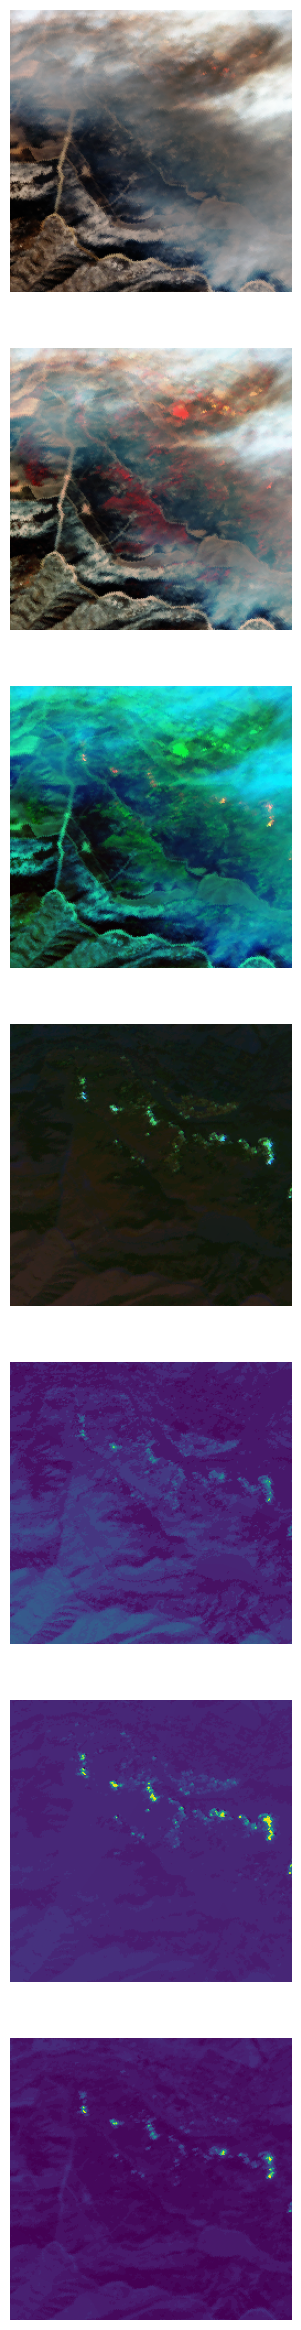

In [35]:
_, (image_batch, label_batch) = next(enumerate(new_test_dataset))

image = (image_batch[0]*255).numpy().astype("uint8")

import matplotlib.pyplot as plt
fig = plt.figure(figsize=(30, 30))

plt.subplot(7, 1, 1)
plt.imshow(image[:,:,[4,2,1]])
plt.axis("off") 

plt.subplot(7, 1, 2)
plt.imshow(image[:,:,[6,4,2]])
plt.axis("off") 

plt.subplot(7, 1, 3)
plt.imshow(image[:,:,[9,6,2]])
plt.axis("off") 

plt.subplot(7, 1, 4)
plt.imshow(image[:,:,[11,10,9]])
plt.axis("off") 

plt.subplot(7, 1, 5)
plt.imshow(image[:,:,[11]])
plt.axis("off") 

plt.subplot(7, 1, 6)
plt.imshow(image[:,:,[10]])
plt.axis("off") 

plt.subplot(7, 1, 7)
plt.imshow(image[:,:,[9]])
plt.axis("off") 



In [36]:
print(classification_model_all_bands.summary())
print(segmentation_model_all_bands.summary())

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 256, 256, 12)]    0         
                                                                 
 conv1 (Conv2D)              (None, 128, 128, 1)       589       
                                                                 
 batch_normalization (BatchN  (None, 128, 128, 1)      4         
 ormalization)                                                   
                                                                 
 maxpool1 (MaxPooling2D)     (None, 64, 64, 1)         0         
                                                                 
 conv3 (Conv2D)              (None, 32, 32, 2)         100       
                                                                 
 batch_normalization_1 (Batc  (None, 32, 32, 2)        8         
 hNormalization)                                             